In [2]:
from nrem_analysis.constant import MOUSE_IDS_TTX, PROCESSED_DIR

import re
import numpy as np
import pynapple as nap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def detect_upstates(
    spikes: nap.TsGroup,
    bin_size = 0.01,
    percentile = 80,
    merge_thr = 0.1,
    short_thr = 0.04,
    long_thr = 2,
    time_units='s'
    ):
    x = spikes.count(bin_size=bin_size, time_units=time_units).sum(axis=1)
    x = x / bin_size
    x = x.smooth(std=2 * bin_size, time_units=time_units)
    thr = np.percentile(x, q=percentile)

    up_states = x.threshold(thr, method='above').time_support
    up_states = up_states.merge_close_intervals(threshold=merge_thr, time_units=time_units)
    up_states = up_states.drop_short_intervals(threshold=short_thr, time_units=time_units)
    up_states = up_states.drop_long_intervals(threshold=long_thr, time_units=time_units)
    return up_states, thr

def extract_sweeps(
    sweeps: nap.Tsd,
    epochs: nap.IntervalSet
    ) -> pd.DataFrame:
    pos = sweeps.values
    times = sweeps.t

    # Assign each sample to its epoch via searchsorted
    starts = epochs['start']
    epoch_idx = np.searchsorted(starts, times, side='right') - 1

    # Split arrays at epoch boundaries
    split_at = np.flatnonzero(np.diff(epoch_idx)) + 1
    pos_chunks = np.split(pos, split_at)
    time_chunks = np.split(times, split_at)

    durations = np.empty(len(pos_chunks))
    net_disp  = np.empty(len(pos_chunks))
    path_len  = np.empty(len(pos_chunks))
    integral  = np.empty(len(pos_chunks))
    n_samples = np.empty(len(pos_chunks), dtype=int)
    t_start   = np.empty(len(pos_chunks))

    for i, (p, t) in enumerate(zip(pos_chunks, time_chunks)):
        uw = np.unwrap(p, period=360)
        durations[i] = t[-1] - t[0]
        net_disp[i]  = np.diff(uw).sum()
        path_len[i]  = np.abs(np.diff(uw)).sum()
        integral[i]  = np.sum(p-p[0])
        n_samples[i] = len(p)
        t_start[i]   = t[0]

    mask = n_samples >= 2
    return pd.DataFrame({
        'duration': durations[mask],
        'net_displacement': net_disp[mask],
        'path_length': path_len[mask],
        'integral': integral[mask],
        'n_samples': n_samples[mask],
        't_start': t_start[mask],
    })

In [52]:
def compute_sweeps(mouse_id):
    data_dir = PROCESSED_DIR / "ttx" / mouse_id
    sleep = nap.load_file(data_dir / "sleep.npz")
    hd_units = nap.load_file(data_dir / "hd_units.npz")
    virtual_hd = nap.load_file(data_dir / "virtual_hd.npz")
    virtual_states = nap.load_file(data_dir / "virtual_states.npz")
    session = nap.load_file(data_dir / "sessions.npz")

    nrem = sleep[sleep["state"] == "nrem"].intersect(
        session[session["label"] == "homecage"]
    )
    cont_eps = virtual_states["continuous"].threshold(0.5).time_support
    up_states, _ = detect_upstates(hd_units.restrict(nrem))
    
    valid_eps = up_states.intersect(cont_eps)
    
    ttx_onset = session[session["label"] == "ttx"].start.item()
    results = extract_sweeps(virtual_hd.restrict(valid_eps), valid_eps)
    results["velocity"] = results["net_displacement"] / results["duration"]
    results["condition"] = np.where(
        results["t_start"] < ttx_onset, "Control", "TTX"
    )
    results["mouse_id"] = mouse_id

    print(f"{mouse_id}: {len(results)} sweeps")
    
    return results

In [53]:
results_by_mouse = [
    compute_sweeps(mouse_id)
    for mouse_id in MOUSE_IDS_TTX
]
results = pd.concat(results_by_mouse, ignore_index=True)

results.groupby(["mouse_id", "condition"]).size().unstack(fill_value=0)

83b: 11885 sweeps
85b: 14974 sweeps
116b: 23281 sweeps
119b: 24666 sweeps


condition,Control,TTX
mouse_id,,
116b,2420,20861
119b,6185,18481
83b,7813,4072
85b,7343,7631


In [ ]:
from nrem_analysis.constant import FIGURES_DIR

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 320,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.linewidth": 0.8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
})

hist_kwargs = dict(
    element="step",
    stat="probability",
    common_norm=False,
    fill=True,
    alpha=0.5,
    palette={"Control": "#d73939", "TTX": "#1d0505ff"},
    hue_order=["Control", "TTX"],
)

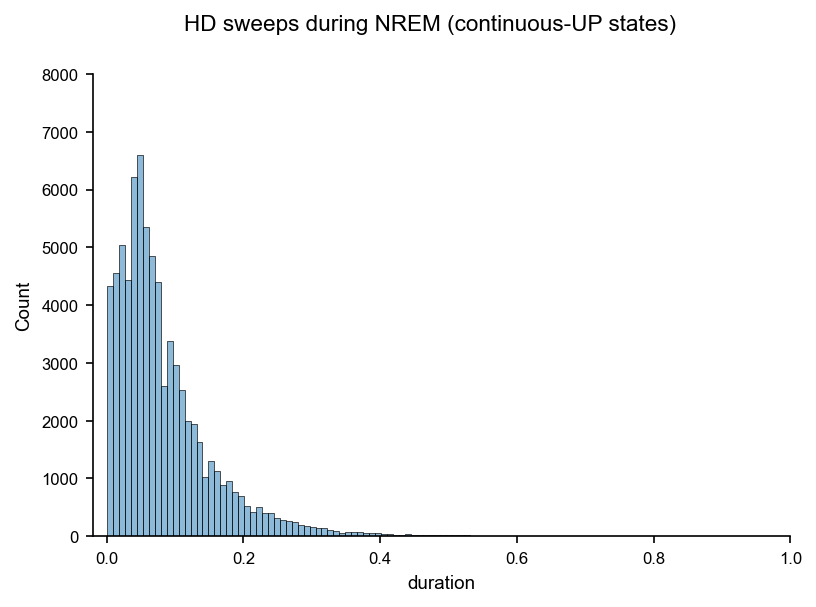

In [55]:
fig, ax = plt.subplots(figsize=(6, 4))

sns.histplot(
    results['duration'],
    stat='count',
    common_norm=False,
    alpha=0.5,
    bins=100,
    ax=ax,
    )

sns.despine()

ax.set_xlim(-.02, 1.)
ax.set_ylim(0, 8000)

fig.suptitle("HD sweeps during NREM (continuous-UP states)")

plt.savefig(FIGURES_DIR / "ttx" / "sweeps_duration_contup.svg", format='svg', bbox_inches='tight')
plt.savefig(FIGURES_DIR / "ttx" / "sweeps_duration_contup.png", format='png', bbox_inches='tight')
plt.show()

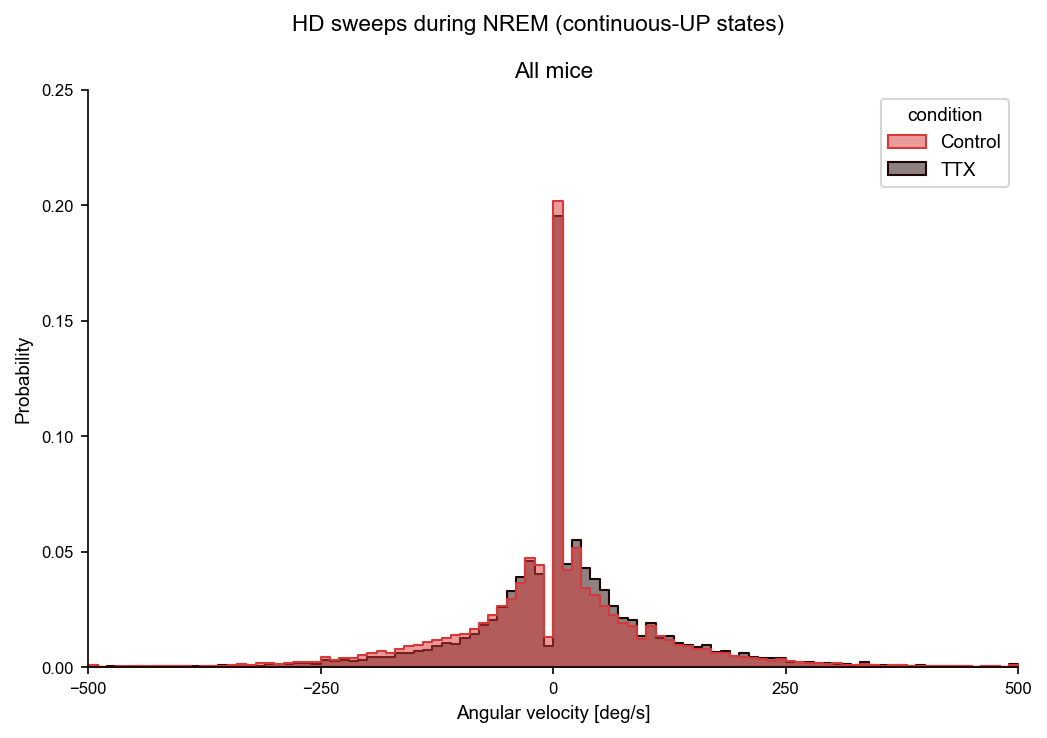

In [61]:
fig, ax = plt.subplots(figsize=(8, 5))

mask = (np.abs(results['velocity']) < 500)
hist_kwargs = dict(
    element="step",
    stat="probability",
    common_norm=False,
    fill=True,
    alpha=0.5,
    palette={"Control": "#d73939", "TTX": "#1d0505ff"},
    hue_order=["Control", "TTX"],
)

sns.histplot(
    data=results[mask],
    x="velocity",
    hue="condition",
    ax=ax,
    **hist_kwargs,
    bins=100,
    )
    
sns.despine()
ax.set_xlim(-500, 500)
ax.set_ylim(0, 0.25)
ax.set_xticks([-500, -250, 0, 250, 500])

ax.set_xlabel("Angular velocity [deg/s]")
ax.set_ylabel("Probability")
ax.set_title("All mice")
fig.suptitle("HD sweeps during NREM (continuous-UP states)")

plt.savefig(FIGURES_DIR / "ttx" / "sweeps_velocity_all_contup.svg", format='svg', bbox_inches='tight')
plt.savefig(FIGURES_DIR / "ttx" / "sweeps_velocity_all_contup.png", format='png', bbox_inches='tight')
plt.show()

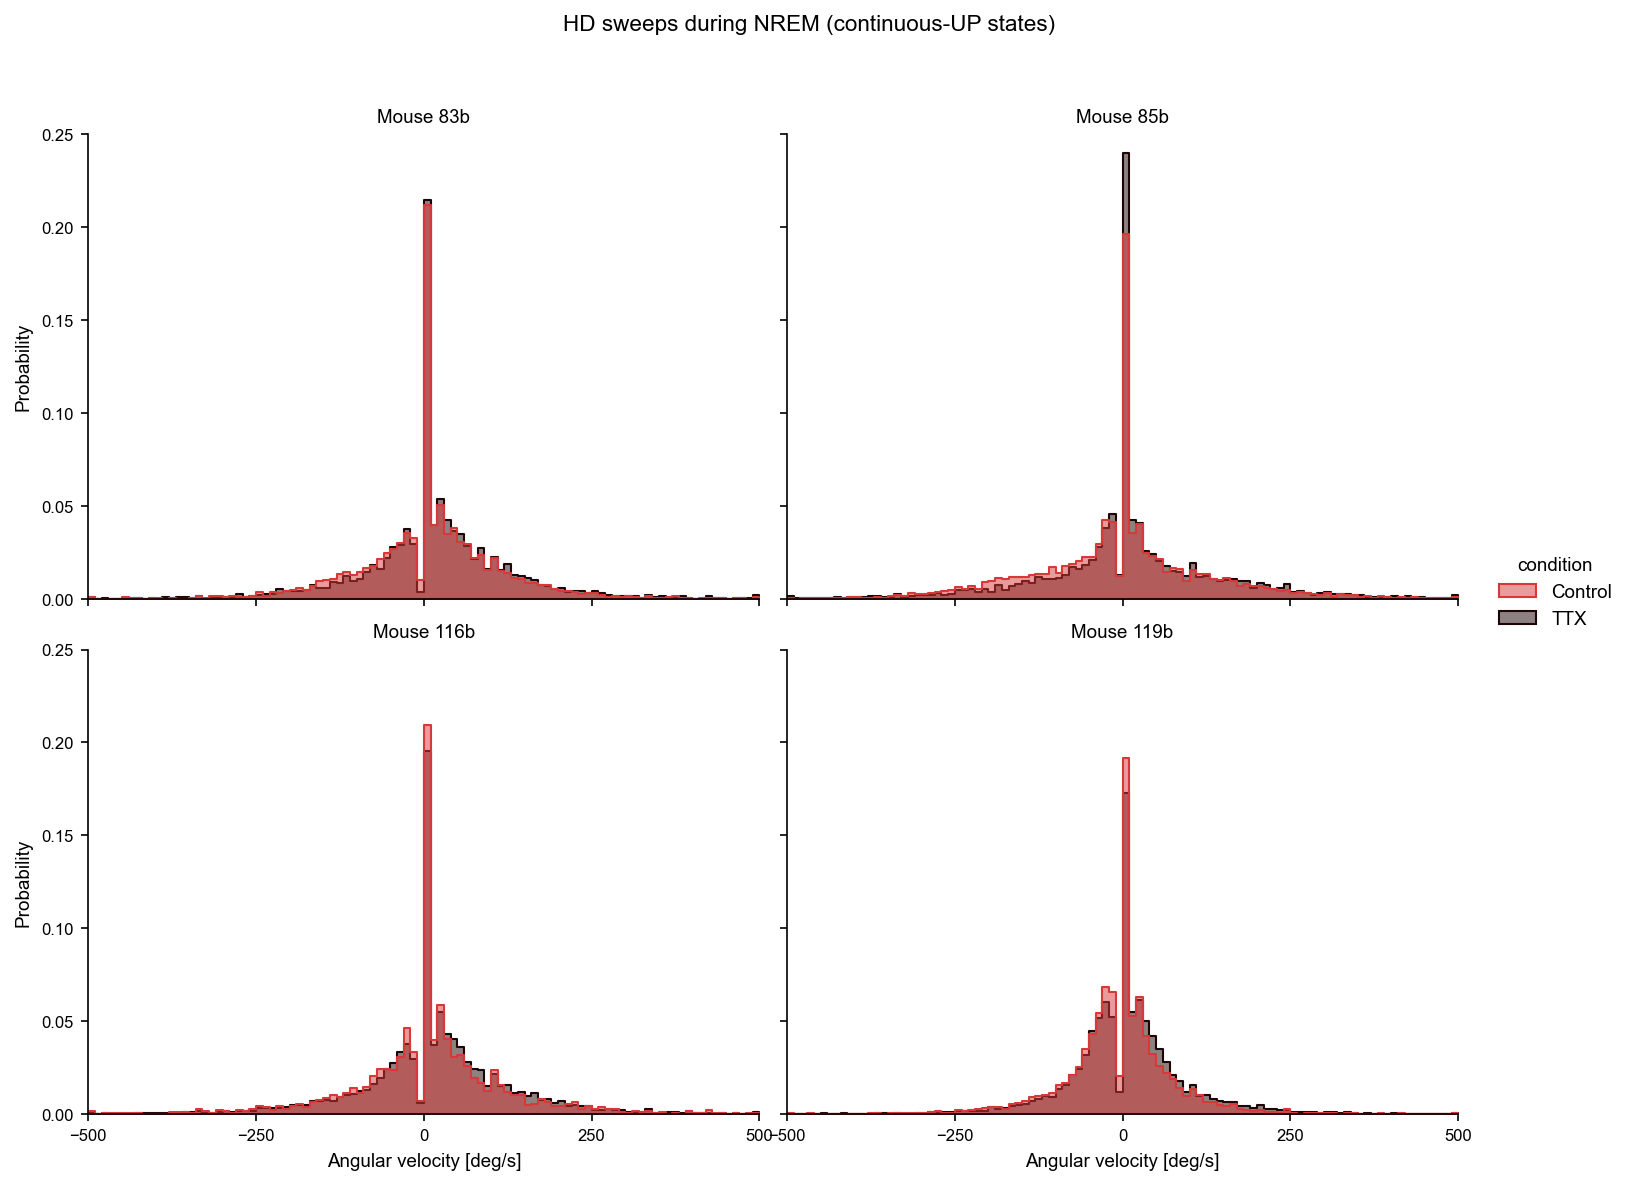

In [65]:
g = sns.displot(
    data=results[mask], x="velocity",
    hue="condition", col="mouse_id",
    col_order=MOUSE_IDS_TTX, col_wrap=2, height=4, aspect=1.25,
    **hist_kwargs,
    bins=100,
)

g.despine()
g.set(xlim=(-500, 500), ylim=(0, 0.25))
g.set(xticks=[-500, -250, 0, 250, 500],)

g.set_axis_labels("Angular velocity [deg/s]", "Probability",)
g.set_titles("Mouse {col_name}")
g.figure.suptitle("HD sweeps during NREM (continuous-UP states)")
g.figure.subplots_adjust(top=0.88)

plt.savefig(FIGURES_DIR / "ttx" / "sweeps_velocity_per_contup.svg", format='svg', bbox_inches='tight')
plt.savefig(FIGURES_DIR / "ttx" / "sweeps_velocity_per_contup.png", format='png', bbox_inches='tight')
plt.show()